<a href="https://colab.research.google.com/github/bidallei/MIAAD-UACJ/blob/main/PreprocesamientoNormalizacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejercicio de preprocesamiento y normalización de texto

**Actividad:** Preparar los datos textuales para que puedan ser analizados o utilizados de manera más eficiente por algoritmos de procesamiento de lenguaje natural (PLN) o modelos de aprendizaje automático

Realizar lo siguiente en un script de Python:<br>
- Genere un script en Python donde aplique las técnicas de preprocesamiento y normalización de texto al dataset indicado (archivo tuits_cambio_climatico.csv) para mostrar en una gráﬁca de barras las primeras 20 palabras con mayor frecuencia y mostrar una nube de palabras.
- No muestre palabras que no aporten algún sentido a los tuits, muestre solo palabras relevantes.
- Para implementar el script utilice funciones.
- El texto de los tuits está almacenado en la columna llamada ‘tuit’ del dataset.
- Para leer los tuits utiliza/investiga la librería Pandas.


### Instalar librería Emoji

In [92]:
!pip install emoji

### Importar librerías que se van a utilizar

In [93]:
import pandas as pd
import numpy as np
import re
import emoji
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

### Cargar archivo tuits_cambio_climatico.csv y verificar que es correcto

In [94]:
# Cargar archivo tuits_cambio_climatico.csv
tuits = pd.read_csv("/content/drive/MyDrive/ClassFiles/tuits_cambio_climatico.csv")
tuits.head()

,tuit
0,Excelente iniciativa de el uso de energías ren...
1,Inspirador que la contaminación plástica afect...
2,Datos muestran que los niveles de CO2 disminuy...
3,Indignante que las temperaturas globales sigan...
4,Inspirador que la deforestación continúe 🌊 #So...


### Función para normalizar texto
Realizaré dos versiones, una en la que se eliminan los hashtags completos #ecoconciencia y otro en los que solo se elimine el símbolo `#`

In [95]:
def normalizar(texto):
  # Elimina los emojis
  texto = emoji.demojize(texto, language= 'es')

  # Hacer todas minúsculas
  texto = texto.lower()

  # Elimina URLs
  texto = re.sub(r'https?://\S+|www\.\S+', '', texto)

  # Elimina correos electrónicos
  texto = re.sub(r'\b[\w\.-]+@[\w\.-]+\.\w{2,4}\b', '', texto)

  # Elimina menciones (@usuario)
  texto = re.sub(r'@\w+', '', texto)

  # Elimina hashtags
  #texto = re.sub(r'#\w+', '', texto)
  texto = re.sub(r'#', '', texto)

  # Elimina todo lo que no son letras, números o espacios
  texto = re.sub(r'[^\w\s]', '', texto)

  # Elimina espacios múltiples y saltos de línea extra
  texto = re.sub(r'\s+', ' ', texto).strip()

  return texto

In [104]:
def normalizar2(texto):
  # Elimina los emojis
  texto = emoji.demojize(texto, language= 'es')

  # Hacer todas minúsculas
  texto = texto.lower()

  # Elimina URLs
  texto = re.sub(r'https?://\S+|www\.\S+', '', texto)

  # Elimina correos electrónicos
  texto = re.sub(r'\b[\w\.-]+@[\w\.-]+\.\w{2,4}\b', '', texto)

  # Elimina menciones (@usuario)
  texto = re.sub(r'@\w+', '', texto)

  # Elimina hashtags
  texto = re.sub(r'#\w+', '', texto)

  # Elimina todo lo que no son letras, números o espacios
  texto = re.sub(r'[^\w\s]', '', texto)

  # Elimina espacios múltiples y saltos de línea extra
  texto = re.sub(r'\s+', ' ', texto).strip()

  return texto

### Función para hacer una lista de las palabras del texto

In [96]:
def listar(texto):
  lista_texto = texto.split()
  return lista_texto

### Función para eliminar *stopwords*

In [97]:
def eliminar_stopwords(lista):
  stopwords = ['el', 'la', 'los', 'las', 'un', 'una', 'unos', 'unas', 'de', 'al', 'en', 'para', 'por', 'con', 'es', 'ser', 'estar', 'y', 'o', 'se', 'u', 'no', 'sí', 'este', 'ese', 'eso', 'a', 'que']
  lista_limpia = [palabra for palabra in lista if palabra not in stopwords]
  return lista_limpia

### Función para contar palabras de una lista en un diccionario

In [98]:
def contar_palabras(lista):
  diccionario = {}
  for palabra in lista:
    if palabra in diccionario:
      diccionario[palabra] += 1
    else:
      diccionario[palabra] = 1
  return diccionario

### Función para ordenar frecuencias de un diccionario

In [99]:
def ordenar_descendente (diccionario):
  lista_ordenada = sorted(diccionario.items(), key=lambda x: x[1], reverse=True)
  return lista_ordenada

## 1. Aplicar funciones al texto

In [100]:
def main():
  tuits_normalizados = tuits['tuit'].apply(normalizar)
  texto_completo = ' '.join(tuits_normalizados)
  tuits_lista = listar(texto_completo)
  tuits_limpios = eliminar_stopwords(tuits_lista)
  tuits_frecuencias = contar_palabras(tuits_limpios)
  tuits_ordenados = ordenar_descendente(tuits_frecuencias)
  return tuits_ordenados

if __name__ == "__main__":
  main()

resultado = main()
top_20 = resultado[:20]
print(top_20)

[('ecoconciencia', 93), ('salvemoselplaneta', 91), ('planeta', 84), ('cambioclimático', 82), ('medioambiente', 78), ('ola_de_mar', 78), ('emisiones', 78), ('gases', 78), ('efecto', 78), ('invernadero', 78), ('reduzcan', 78), ('uso', 72), ('energías', 72), ('renovables', 72), ('expanda', 72), ('sostenibilidad', 72), ('advertencia', 71), ('corazón_verde', 68), ('temperaturas', 67), ('globales', 67)]


### Realizar una gráfica con las 20 palabras más usadas


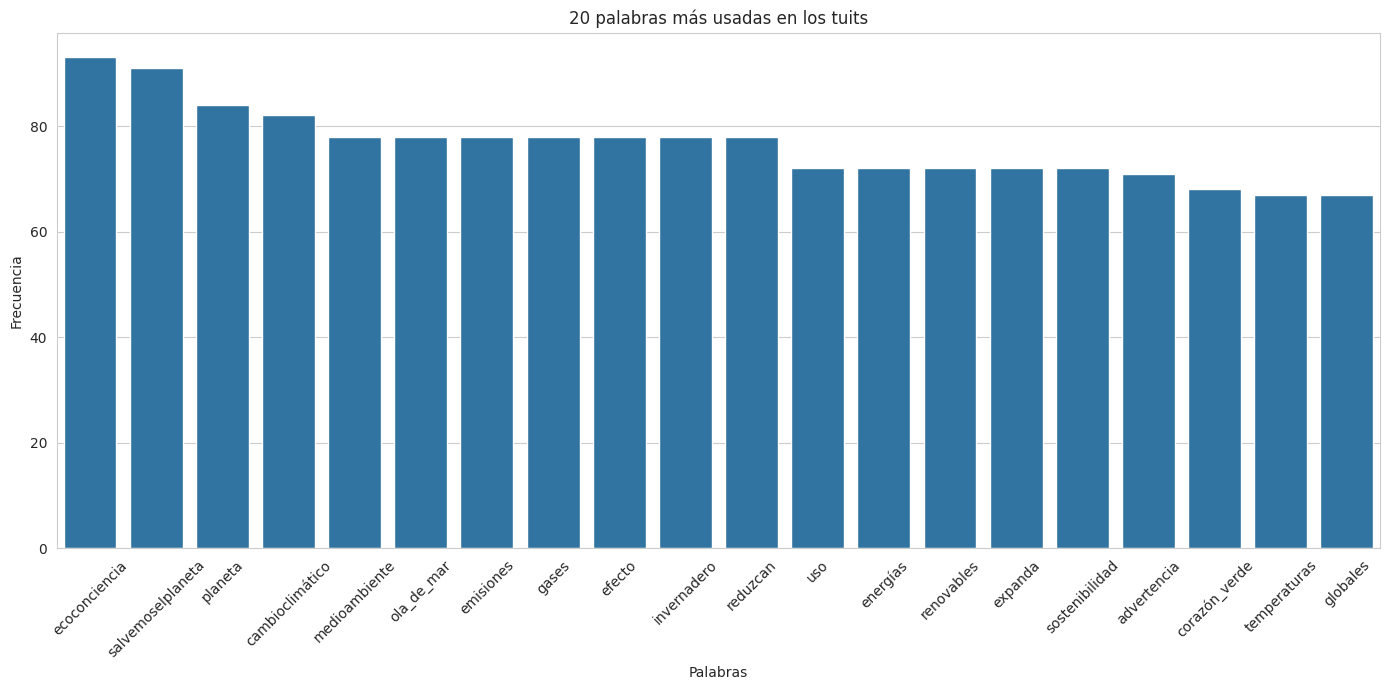

In [101]:
sns.set_style('whitegrid')
plt.figure(figsize=(14, 7))

palabras, frecuencias = zip(*top_20)
grafica = sns.barplot(x=palabras, y=frecuencias)

plt.xlabel('Palabras')
plt.xticks(rotation=45)

plt.ylabel('Frecuencia')
plt.title('20 palabras más usadas en los tuits')

plt.tight_layout()
plt.show()

### Realizar nube de palabras

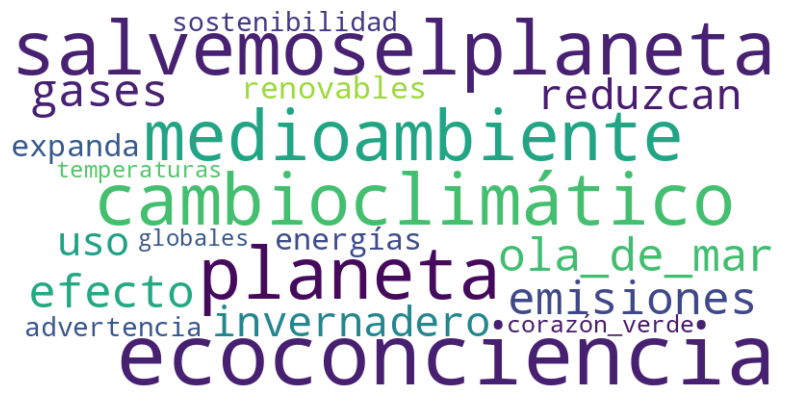

In [102]:
top_20_dict = dict(top_20)
wc = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis',
    random_state=42
)
wc.generate_from_frequencies(top_20_dict)
plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()

## 2. Aplicar funciones al texto

In [105]:
def main2():
  tuits_normalizados = tuits['tuit'].apply(normalizar2)
  texto_completo = ' '.join(tuits_normalizados)
  tuits_lista = listar(texto_completo)
  tuits_limpios = eliminar_stopwords(tuits_lista)
  tuits_frecuencias = contar_palabras(tuits_limpios)
  tuits_ordenados = ordenar_descendente(tuits_frecuencias)
  return tuits_ordenados

if __name__ == "__main__":
  main2()

resultado2 = main2()
top_20_2 = resultado2[:20]
print(top_20_2)

[('ola_de_mar', 78), ('emisiones', 78), ('gases', 78), ('efecto', 78), ('invernadero', 78), ('reduzcan', 78), ('uso', 72), ('energías', 72), ('renovables', 72), ('expanda', 72), ('advertencia', 71), ('corazón_verde', 68), ('temperaturas', 67), ('globales', 67), ('sigan', 67), ('aumentando', 67), ('fuego', 65), ('contaminación', 62), ('plástica', 62), ('afecte', 62)]


### Realizar una gráfica con las 20 palabras más usadas


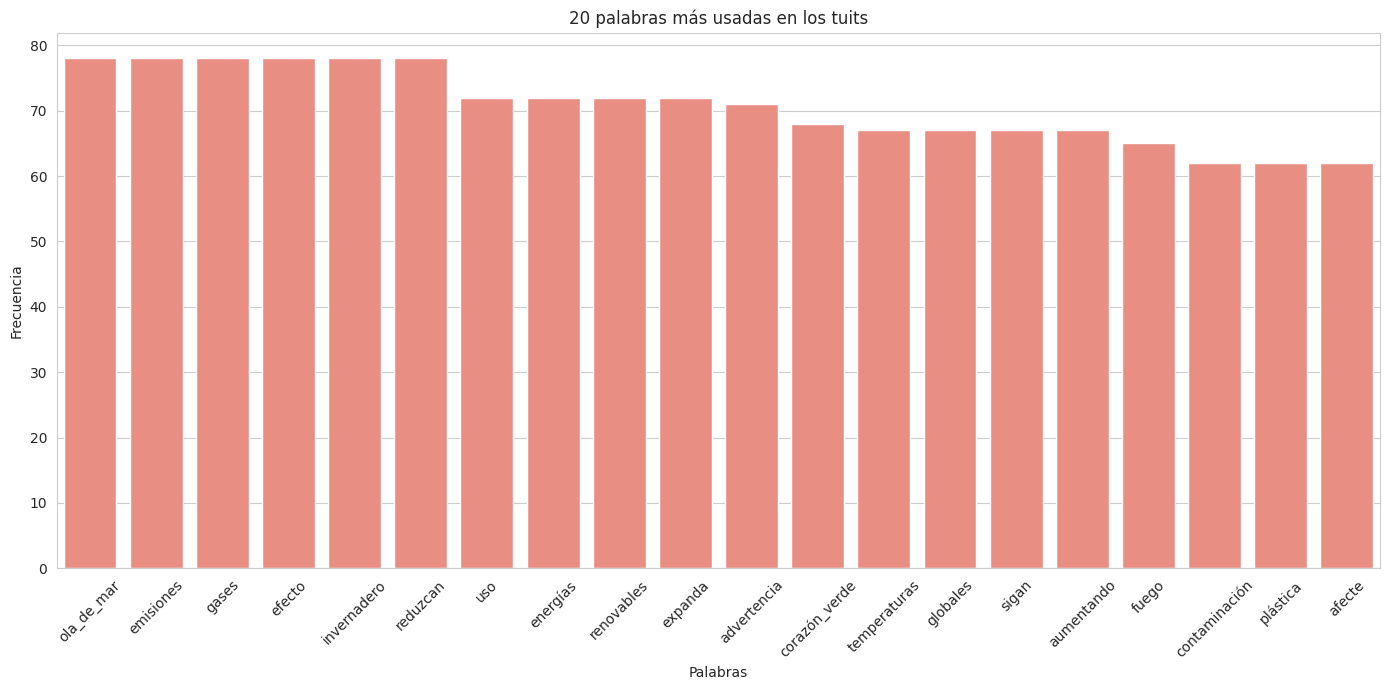

In [111]:
sns.set_style('whitegrid')
plt.figure(figsize=(14, 7))

palabras2, frecuencias2 = zip(*top_20_2)
grafica2 = sns.barplot(x=palabras2, y=frecuencias2, color='salmon')

plt.xlabel('Palabras')
plt.xticks(rotation=45)

plt.ylabel('Frecuencia')
plt.title('20 palabras más usadas en los tuits')

plt.tight_layout()
plt.show()

### Realizar nube de palabras

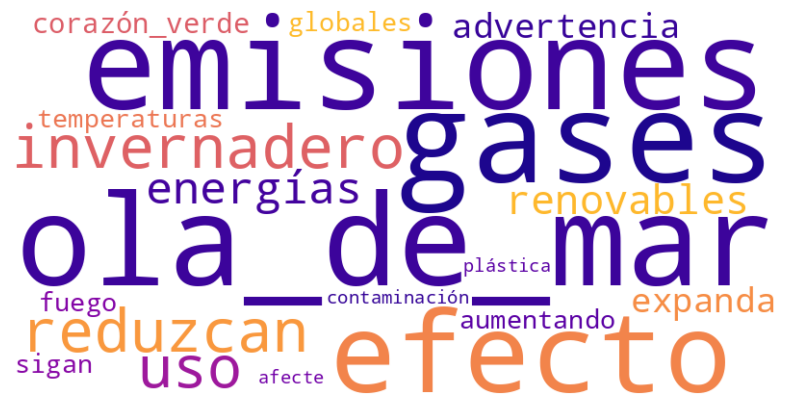

In [117]:
top_20_dict2 = dict(top_20_2)
wc = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='plasma',
    random_state=42
)
wc.generate_from_frequencies(top_20_dict2)
plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()